# Bandidos de $k$ brazos

Vamos a usar GymBandits, una libreria diseñada para ser utilizada sobre OpenAi Gym (https://github.com/openai/gym/) pero orientada a Armed Bandits.

Instalación:

```
git clone https://github.com/JKCooper2/gym-bandits.git
cd gym-bandits
pip install git+https://github.com/JKCooper2/gym-bandits.git
```


In [ ]:
!git clone https://github.com/JKCooper2/gym-bandits.git
!cd gym-bandits
!pip install git+https://github.com/JKCooper2/gym-bandits.git

## Preparativos para nuestros experimentos

In [4]:
import gym
import random
import gym_bandits
import numpy as np
import matplotlib.pyplot as plt

from agent import Agent

import warnings
warnings.filterwarnings('ignore')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [5]:
# Compatibilidad entre versiones nuevas de NumPy y Gym
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

Elegimos el ambiente descripto arriba. En gym-bandits/README.md se describen otros ambientes

In [6]:
env = gym.make("BanditTenArmedGaussian-v0")

¿Cuántas acciones (brazos) disponibles hay?

In [7]:
print(env.action_space.n)

10


Definimos algunas variables que vamos a usar en los experimentos

In [8]:
# Duración de cada experimentación.
number_steps = 2500

# Cantidad de experimentaciones usadas para generar gráficos.
number_runs = 100

# Diccionarios donde vamos a guardar las series de mean rewards y porcentaje
# de optimal actions para cada agente. Clave: nombre del agente, Valor: series.
results_rewards = dict()
results_optimal = dict()

Definimos las funciones que vamos a usar para crear los gráficos

In [9]:
def calculate_mean_rewards_and_selected_optimal_action_by_step(n_runs:int, n_steps:int, agent, env) \
            -> tuple[list[float], list[float]]:
    '''
    Ejecuta n_runs experimentaciones, cada una de longitud n_steps, del agente dado sobre el ambiente env.
    Devuelve una tupla de dos listas: las recompensas medias y los porcentajes de veces que se eligió la
    mejor acción en cada momento del tiempo, promediando sobre todas las experimentaciones.
    '''
    many_rewards = []
    many_selected_best_action = []
    for i in range(n_runs):
        # Ejecución de una experimentación de n_steps, con este agente en este ambiente.
        logs, info = agent.play(n_steps, env)
        many_rewards.append(logs['rewards'])
        many_selected_best_action.append(logs['selected_best_action'])
    mean_rewards = np.mean(many_rewards, axis = 0)
    mean_selected_best_action = np.mean(many_selected_best_action, axis = 0)
    return (mean_rewards, mean_selected_best_action)

def plot_results(results:dict[str,list[float]], plot_title, x_label, y_label, n_steps):
    '''
    Genera un gráfico de varias series temporales guardadas en results.
    results es un dict: nombre --> lista de valores a plotear.
    '''
    plt.figure(figsize=(10,5))
    for name, values in results.items():
        plt.plot(range(n_steps), values, label=name)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(plot_title)
    plt.legend()
    plt.show()

## Agente de comportamiento aleatorio

In [10]:
class RandomAgent(Agent):
    def __init__(self, name):
        super().__init__(name)

    def reset_internal_state(self):
        pass

    def select_action(self, game_state):
        return self.environment.action_space.sample()

    def update_internal_state(self, observation, action, reward): # no usa la informacion para aprender
        pass

    def get_extra_info(self):
        return None

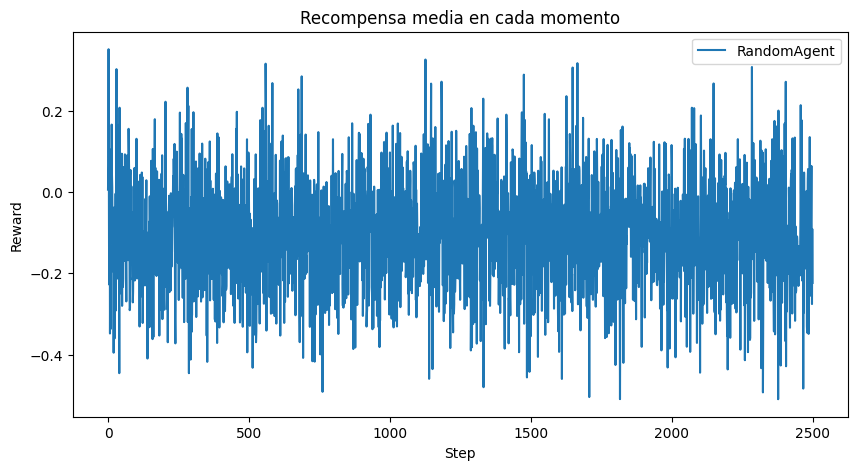

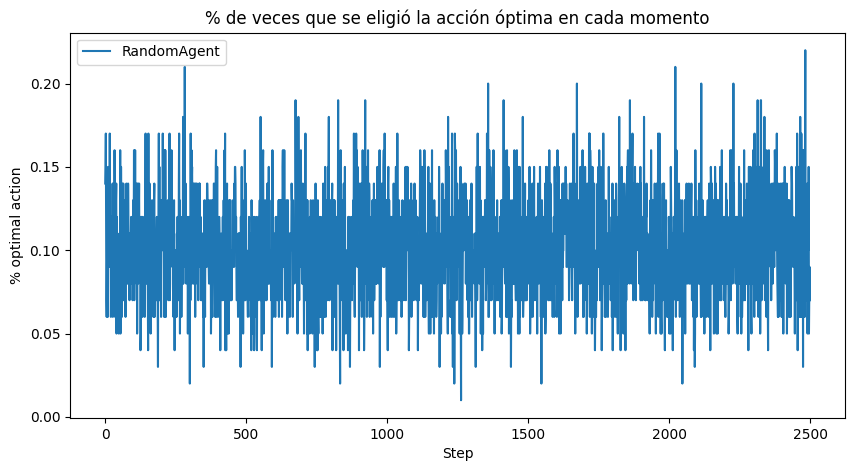

In [11]:
(rewards, optimal) = calculate_mean_rewards_and_selected_optimal_action_by_step(
            number_runs, number_steps, RandomAgent("RandomAgent"), env)

results_rewards['RandomAgent'] = list(rewards)
results_optimal['RandomAgent'] = list(optimal)

plot_results(results_rewards, "Recompensa media en cada momento", "Step", "Reward", number_steps)
plot_results(results_optimal, "% de veces que se eligió la acción óptima en cada momento", "Step", "% optimal action", number_steps)


- El reward es el promedio de la ganancia de todos los agentes en cada step
- % optimal action es la curva de aprendizaje

1. **¿Qué podemos inferir del gráfico de % optimal action?**
2. **¿Qué pasaría si ejecutáramos el agente aleatorio por 10,000 pasos en lugar de 2,500? ¿Cambiaría significativamente su rendimiento promedio?**

## Agente que explora todo una vez, luego explota lo aprendido

In [12]:
class ExploreOnceAgent(Agent):
    def __init__(self, name):
        self.time:int = 0         # Cantidad de veces que invocamos select_action
        self.best_arm:int = 0     # Brazo que arrojó la mejor recompensa hasta ahora
        self.best_reward:float = -float('inf')  # Mejor recompensa obtenida hasta ahora
        super().__init__(name)

    def reset_internal_state(self):
        self.time = 0
        self.best_arm = 0
        self.best_reward = -float('inf')

    def select_action(self, game_state):
        if self.time < self.environment.action_space.n:
            # Todavia estoy explorando.
            return self.time
        else:
            # Ya no exploro más, ahora exploto lo aprendido.
            return self.best_arm

    def update_internal_state(self, observation, action, reward):
        if self.time < self.environment.action_space.n:
            # Todavia estoy explorando
            if reward > self.best_reward:
                self.best_reward = reward
                self.best_arm = self.time   # el último brazo elegido
        else:
            # Estoy explotando, ya no quiero aprender nada nuevo.
            pass
        self.time += 1

    def get_extra_info(self):
        return None

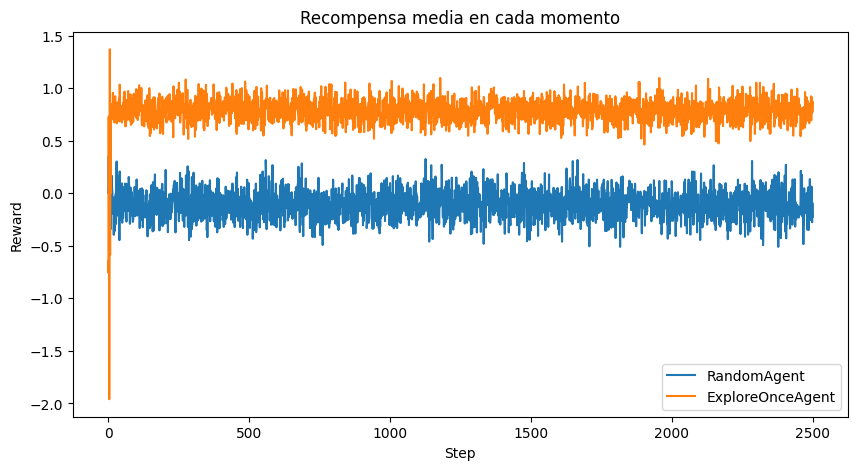

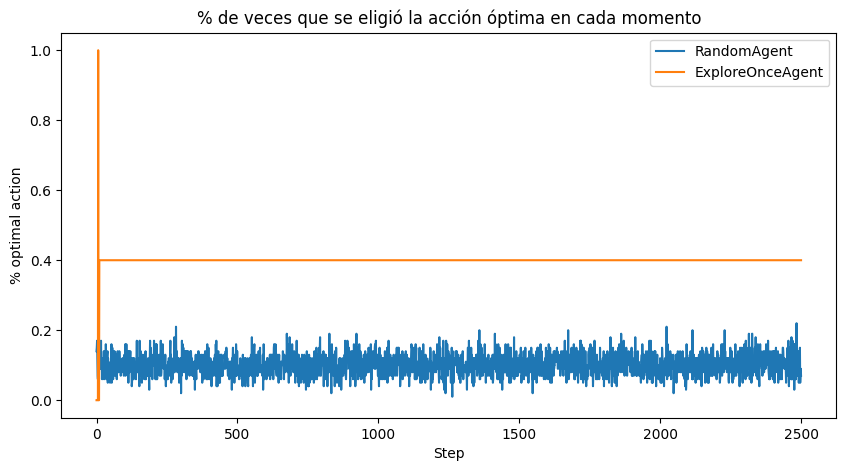

In [13]:
(rewards,optimal) = calculate_mean_rewards_and_selected_optimal_action_by_step(
            number_runs, number_steps, ExploreOnceAgent("ExploreOnceAgent"), env)
results_rewards['ExploreOnceAgent'] = list(rewards)
results_optimal['ExploreOnceAgent'] = list(optimal)

plot_results(results_rewards, "Recompensa media en cada momento", "Step", "Reward", number_steps)
plot_results(results_optimal, "% de veces que se eligió la acción óptima en cada momento", "Step", "% optimal action", number_steps)

1. **¿A qué podemos atribuir el hecho de que la curva de Reward sea mayor?**
2. **¿Por qué si solo explora una vez y luego siempre juega la misma palanca la curva de reward tiene oscilaciones?**

## Agente que explora todo $n$ veces, luego explota lo aprendido

In [14]:
class ExploreNTimesAgent(Agent):
    def __init__(self, name, n:int):
        self.n:int = n
        self.time:int = 0         # Cantidad de veces que invocamos select_action.
        self.best_arm:int = 0     # Brazo que arrojó la mejor recompensa hasta ahora.
        self.best_reward:float = -float('inf')  # Mejor recompensa obtenida hasta ahora.
        super().__init__(name)

    def reset_internal_state(self):
        self.time = 0
        self.best_arm = 0
        self.best_reward = -float('inf')

    def select_action(self, game_state):
        if self.time < self.environment.action_space.n * self.n:
            # Todavia estoy explorando.
            return self.time % self.environment.action_space.n
        else:
            # Ya no exploro más, ahora exploto lo aprendido.
            return self.best_arm

    def update_internal_state(self, observation, action, reward):
        if self.time < self.environment.action_space.n * self.n:
            # Todavia estoy explorando
            if reward > self.best_reward:
                self.best_reward = reward
                self.best_arm = self.time % self.environment.action_space.n  # el último brazo elegido
        else:
            # Estoy explotando, ya no quiero aprender nada nuevo.
            pass
        self.time += 1

    def get_extra_info(self):
        return None

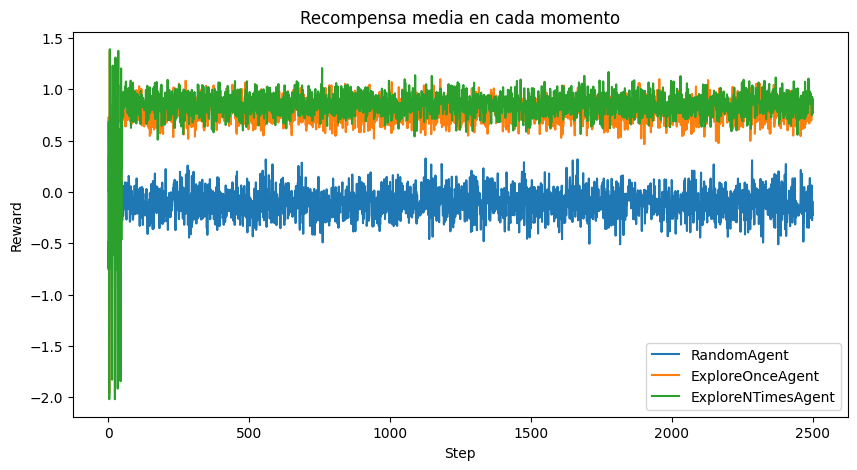

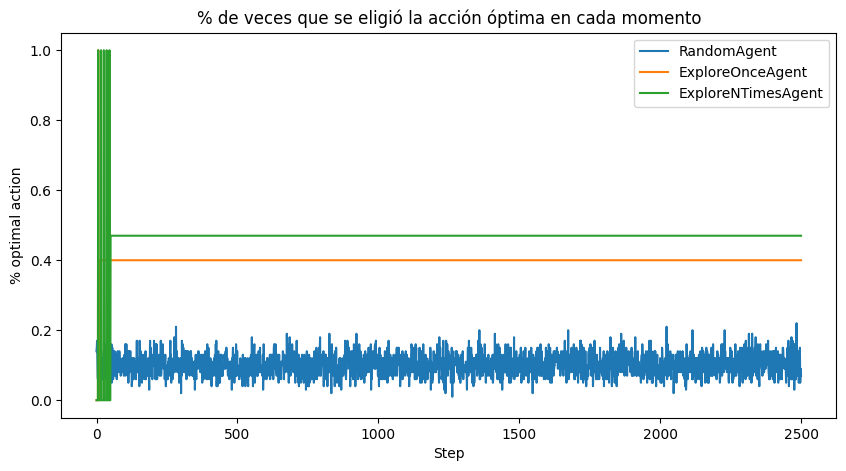

In [15]:
(rewards,optimal) = calculate_mean_rewards_and_selected_optimal_action_by_step(
            number_runs, number_steps, ExploreNTimesAgent("ExploreNTimesAgent", 5), env)
results_rewards['ExploreNTimesAgent'] = list(rewards)
results_optimal['ExploreNTimesAgent'] = list(optimal)

plot_results(results_rewards, "Recompensa media en cada momento", "Step", "Reward", number_steps)
plot_results(results_optimal, "% de veces que se eligió la acción óptima en cada momento", "Step", "% optimal action", number_steps)

1. **¿Por qué explorar cada brazo 5 veces en lugar de 1 vez nos da más confianza en nuestra elección?**
2. **¿Que efecto esperamos que tenga aumentar el tamaño de N?**

### Agente $\epsilon$-greedy

In [16]:
class EpsilonGreedyAgent(Agent):
    def __init__(self, name, epsilon):
        super().__init__(name)
        self.epsilon = epsilon

    def reset_internal_state(self):
        self.n_a = np.zeros(self.environment.action_space.n)
        self.q_a = np.zeros(self.environment.action_space.n)

    def select_action(self, game_state):
        rnd = random.random()
        exploit = rnd > self.epsilon # explota si el numero random es mayor a e
        if exploit:
              action = np.argmax(self.q_a)
        else:
              action = self.environment.action_space.sample() # acción aleatoria
        return action

    def update_internal_state(self, observation, action, reward):
        self.n_a[action]+=1
        alpha = 1/self.n_a[action]
        self.q_a[action] = self.q_a[action] + alpha*(reward - self.q_a[action])

    def get_extra_info(self):
        return {'q_a': self.q_a, 'n_a': self.n_a}

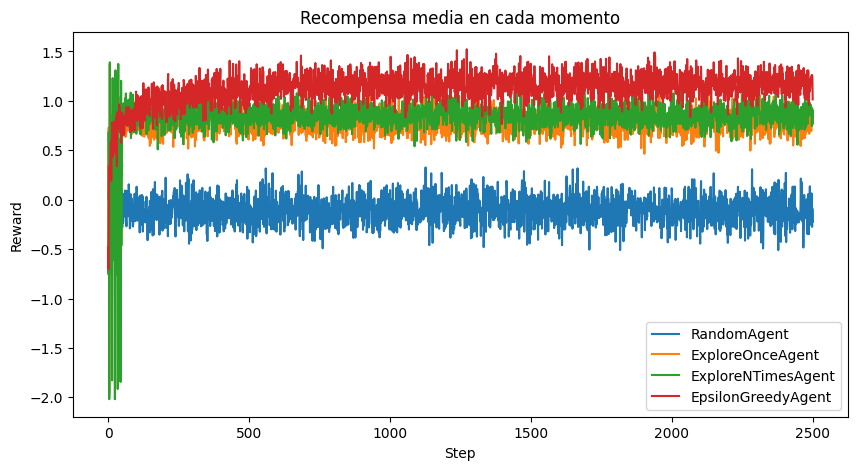

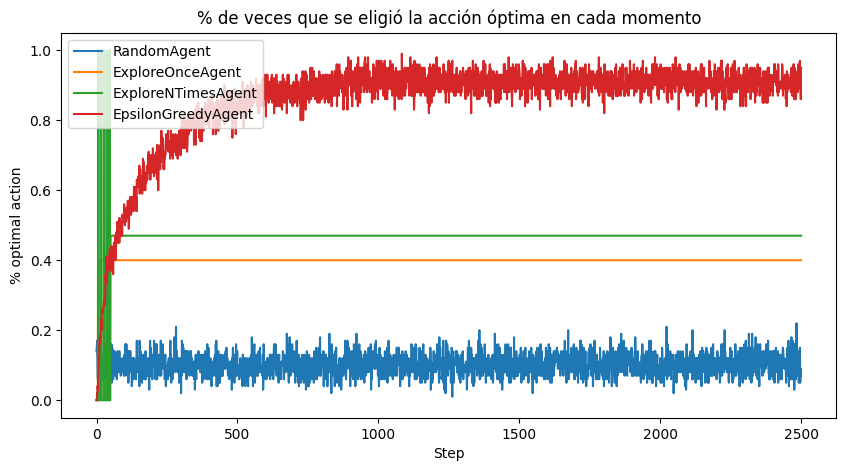

In [17]:
(rewards,optimal) = calculate_mean_rewards_and_selected_optimal_action_by_step(
            number_runs, number_steps, EpsilonGreedyAgent("EpsilonGreedyAgent", 0.1), env)
results_rewards['EpsilonGreedyAgent'] = list(rewards)
results_optimal['EpsilonGreedyAgent'] = list(optimal)

plot_results(results_rewards, "Recompensa media en cada momento", "Step", "Reward", number_steps)
plot_results(results_optimal, "% de veces que se eligió la acción óptima en cada momento", "Step", "% optimal action", number_steps)

1. **¿Qué podemos inferir de la forma de la curva de % optimal action del Agente que sigue la estrategia $\epsilon$-greedy?**
2. **¿Por qué el agente ε-greedy puede seguir mejorando incluso después de muchos pasos, a diferencia de los agentes que solo exploran al principio?**
3. **¿Qué pasaría si usáramos ε = 0.5 en lugar de ε = 0.1? ¿Cómo afectaría esto al balance entre exploración y explotación?**
4. **Experimentar y observar que ocurre al variar los valores de $\epsilon$**


### Agente $\epsilon$-greedy con TasaAct = $\alpha$

In [18]:
class NonStationaryEpsilonGreedyAgent(Agent):
    def __init__(self, name, epsilon, alpha):
        super().__init__(name)
        self.epsilon = epsilon
        self.alpha = alpha

    def reset_internal_state(self):
        self.n_a = np.zeros(self.environment.action_space.n)
        self.q_a = np.zeros(self.environment.action_space.n)

    def select_action(self, game_state):
        rnd = random.random()
        exploit = rnd > self.epsilon
        if exploit:
            action = np.argmax(self.q_a)
        else:
            action = self.environment.action_space.sample()
        return action

    def update_internal_state(self, observation, action, reward):
        # Nota: ahora no usamos 1/n_a[action] como tasa,
        # usamos alpha fijo
        self.n_a[action] += 1
        self.q_a[action] = self.q_a[action] + self.alpha * (reward - self.q_a[action])

    def get_extra_info(self):
        return {'q_a': self.q_a, 'n_a': self.n_a}

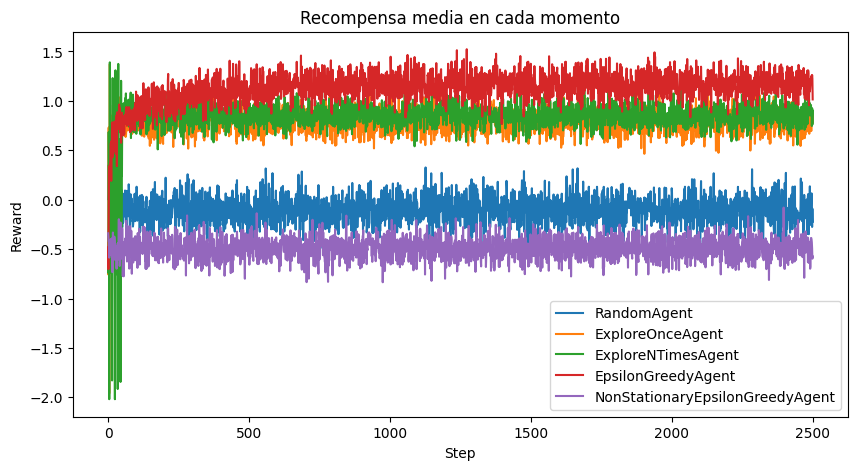

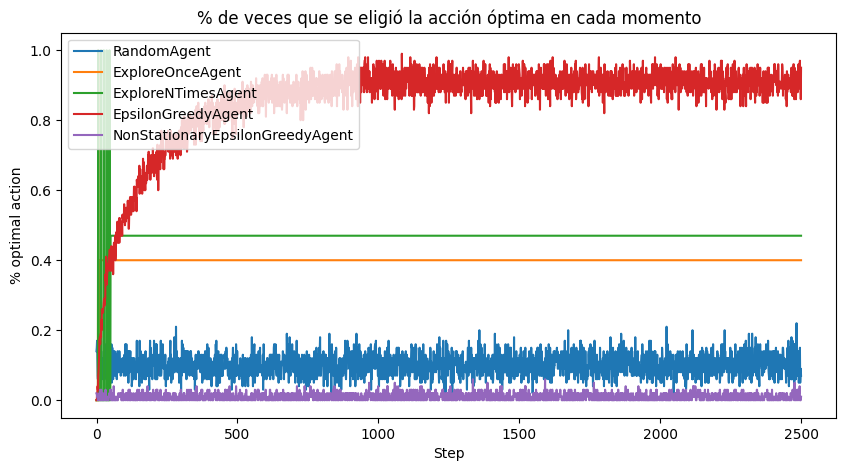

In [19]:
(rewards,optimal) = calculate_mean_rewards_and_selected_optimal_action_by_step(
            number_runs, number_steps, NonStationaryEpsilonGreedyAgent("NonStationaryEpsilonGreedyAgent", 0.1, 0), env)
results_rewards['NonStationaryEpsilonGreedyAgent'] = list(rewards)
results_optimal['NonStationaryEpsilonGreedyAgent'] = list(optimal)

plot_results(results_rewards, "Recompensa media en cada momento", "Step", "Reward", number_steps)
plot_results(results_optimal, "% de veces que se eligió la acción óptima en cada momento", "Step", "% optimal action", number_steps)

1. **¿Por qué un $\alpha$ más grande se puede adaptar mejor a cambios repentinos?**
2. **¿Qué ventaja tiene usar $\alpha$ chico en un entorno estable?**
3. **¿Cuál es la diferencia intuitiva entre usar como tasa de activación el promedio vs. usar una tasa de activación fija?**
4. **Experimentar y observar que ocurre al variar los valores de $\alpha$**

## Agente con estrategia personalizada

In [20]:
class CustomAgent(Agent):
    def __init__(self, name):
        super().__init__(name)

        # Agregar acá los parámetros que necesite la estrategia.

    def reset_internal_state(self):
        # Estado inicial
        # Inicializar acá las variables necesarias para aprender.
        self.n_a = np.zeros(self.environment.action_space.n)
        self.q_a = np.zeros(self.environment.action_space.n)


    def select_action(self, game_state):
        # Definir acá cómo se elige la próxima acción.
        # Por defecto elegir una acción aleatoria.
        action = self.environment.action_space.sample() # Reemplazar

        return action


    def update_internal_state(self, observation, action, reward):
        # Aprendizaje o Train
        # Actualización por promedio muestral.
        self.n_a[action] += 1
        alpha = 1 / self.n_a[action]
        self.q_a[action] = self.q_a[action] + alpha * (reward - self.q_a[action])


    def get_extra_info(self):
        return {'q_a': self.q_a, 'n_a': self.n_a}

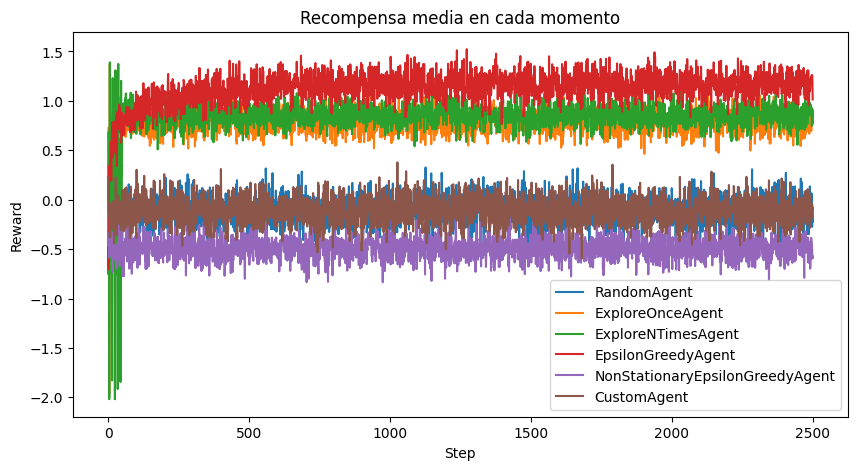

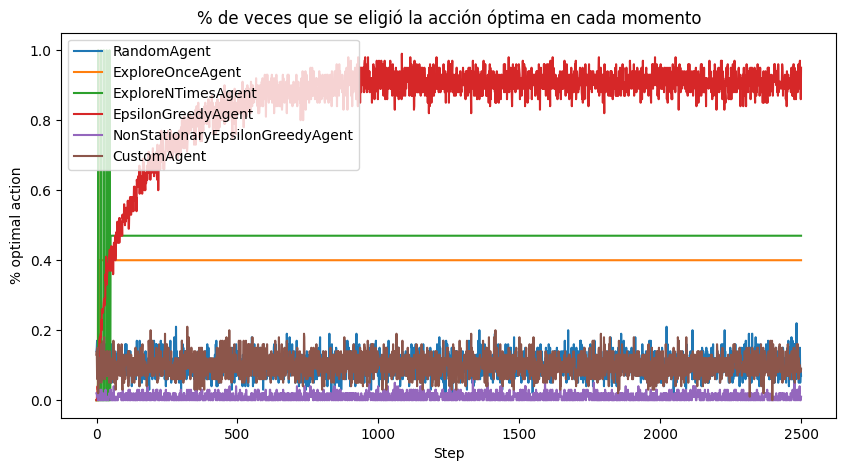

In [21]:
(rewards, optimal) = calculate_mean_rewards_and_selected_optimal_action_by_step(
            number_runs, number_steps, CustomAgent("CustomAgent"), env)

results_rewards['CustomAgent'] = list(rewards)
results_optimal['CustomAgent'] = list(optimal)

plot_results(results_rewards, "Recompensa media en cada momento", "Step", "Reward", number_steps)
plot_results(results_optimal, "% de veces que se eligió la acción óptima en cada momento", "Step", "% optimal action", number_steps)